Memproses gambar: lurus.png...


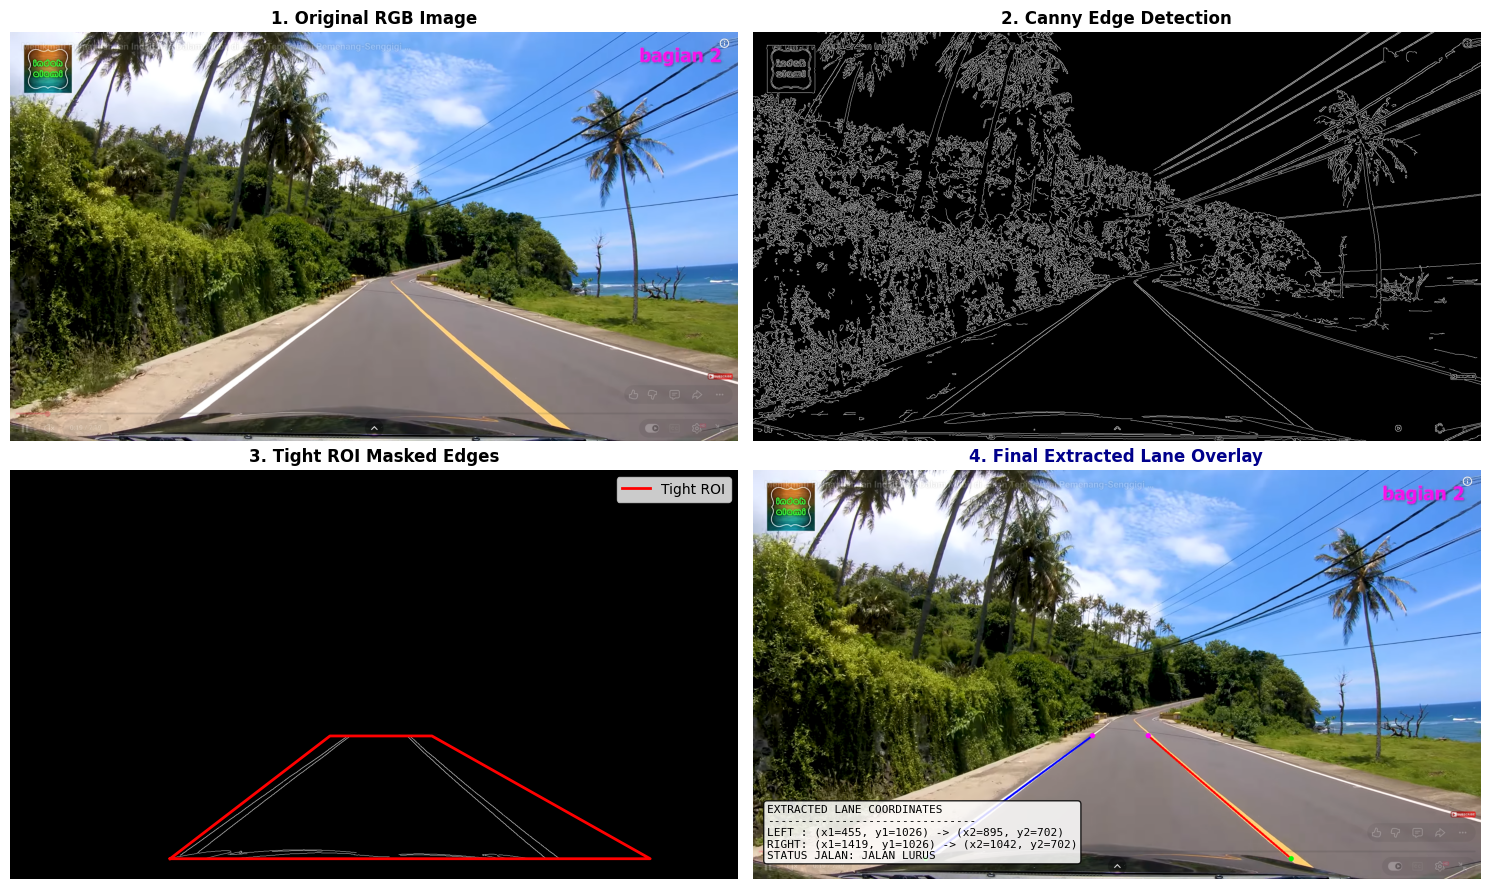


Status Geometris: JALAN LURUS
Koordinat Kiri : {'x1': 455, 'y1': 1026, 'x2': 895, 'y2': 702, 'slope': -0.7354, 'status': 'DETECTED'}
Koordinat Kanan: {'x1': 1419, 'y1': 1026, 'x2': 1042, 'y2': 702, 'slope': 0.8613, 'status': 'DETECTED'}


In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Tuple, Optional, Any

# ==============================================================================
# HYPERPARAMETERS & CONSTANTS
# ==============================================================================
GAUSSIAN_KERNEL = (5, 5)
GAUSSIAN_SIGMA = 1.0

# Threshold Canny Edge Detection
CANNY_LOW_THRESHOLD = 50
CANNY_HIGH_THRESHOLD = 150

# Parameter Probabilistic Hough Line Transform (cv2.HoughLinesP)
HOUGHP_RHO = 1             # Resolusi jarak akumulator (1 pixel)
HOUGHP_THETA = np.pi / 180 # Resolusi sudut akumulator (1 derajat)
HOUGHP_THRESHOLD = 20      # Minimum vote pada ruang Hough
HOUGHP_MIN_LINE_LEN = 20   # Panjang segmen garis minimal (pixel)
HOUGHP_MAX_LINE_GAP = 30   # Batas celah piksel kosong untuk disambung

OUTPUT_PNG_PATH = 'lane_detection_result.png'


# ==============================================================================
# PIPELINE FUNCTIONS
# ==============================================================================

def preprocess_image(image_path: str) -> Tuple[np.ndarray, np.ndarray]:
    """Membaca gambar dari disk, konversi ke Grayscale, dan Gaussian Blur."""
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"File gambar tidak ditemukan: {image_path}")

    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"Gagal membaca gambar dari: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    blurred_gray = cv2.GaussianBlur(gray, GAUSSIAN_KERNEL, GAUSSIAN_SIGMA)

    return img_rgb, blurred_gray


def apply_canny_edge_detection(blurred_image: np.ndarray) -> np.ndarray:
    """Deteksi tepi menggunakan Canny Edge Detection."""
    return cv2.Canny(blurred_image, CANNY_LOW_THRESHOLD, CANNY_HIGH_THRESHOLD)


def define_and_apply_tight_roi(edges: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Membentuk Tight ROI Trapezium yang presisi.
    Batas bawah kiri disempitkan agar pembatas jalan/curb beton di sisi kiri terpotong.
    """
    height, width = edges.shape[:2]

    # Batas Vertikal ROI (Horizon Y)
    top_y = int(height * 0.65)     # Menurunkan horizon agar tidak menangkap pepohonan
    bottom_y = int(height * 0.95)  # Batas bawah dekat kap mobil

    # Batas Horizontal ROI (Kooridnat X)
    top_left_x = int(width * 0.44)
    top_right_x = int(width * 0.58)
    bottom_left_x = int(width * 0.22)  # Digeser dari 0.12 ke 0.22 untuk membuang curb beton kiri
    bottom_right_x = int(width * 0.88)

    roi_corners = np.array([[
        [bottom_left_x, bottom_y],
        [top_left_x, top_y],
        [top_right_x, top_y],
        [bottom_right_x, bottom_y]
    ]], dtype=np.int32)

    mask = np.zeros_like(edges)
    cv2.fillPoly(mask, roi_corners, 255)
    masked_edges = cv2.bitwise_and(edges, mask)

    return masked_edges, roi_corners


def extract_lane_coordinates(lines: Optional[np.ndarray],
                             img_shape: Tuple[int, int]) -> Dict[str, Any]:
    """
    Mengekstrak segmen HoughLinesP dan mengelompokkan marka Kiri & Kanan.
    Penyaringan slope diperketat untuk mengabaikan garis curb beton.
    """
    height, width = img_shape
    y_min = int(height * 0.65)
    y_max = int(height * 0.95)

    left_fits = []
    right_fits = []

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line.ravel()

            if x1 == x2:
                continue

            slope = (y2 - y1) / (x2 - x1)
            intercept = y1 - (slope * x1)

            # Filter noise: Garis terlalu landai atau terlalu curam
            if abs(slope) < 0.45 or abs(slope) > 2.0:
                continue

            # Filter Kanan vs Kiri berbasis slope dan posisi sumbu X
            # Sisi Kiri: Slope negatif dan titik x1 berada di separuh kiri area jalan
            if slope < 0 and (width * 0.20 < x1 < width * 0.50):
                left_fits.append((slope, intercept))
            # Sisi Kanan: Slope positif dan titik x1 berada di separuh kanan
            elif slope > 0 and (width * 0.50 <= x1 < width * 0.90):
                right_fits.append((slope, intercept))

    def calculate_endpoints(fits: list) -> Dict[str, Any]:
        if not fits:
            return {"x1": 0, "y1": 0, "x2": 0, "y2": 0, "slope": 0.0, "status": "NOT_DETECTED"}

        avg_fit = np.mean(fits, axis=0)
        slope, intercept = avg_fit[0], avg_fit[1]

        x1 = int((y_max - intercept) / slope)
        x2 = int((y_min - intercept) / slope)

        x1 = max(0, min(width - 1, x1))
        x2 = max(0, min(width - 1, x2))

        return {
            "x1": x1, "y1": y_max,
            "x2": x2, "y2": y_min,
            "slope": float(round(slope, 4)),
            "status": "DETECTED"
        }

    return {
        "left_lane": calculate_endpoints(left_fits),
        "right_lane": calculate_endpoints(right_fits)
    }


def analyze_road_curvature(left_lane: Dict[str, Any], right_lane: Dict[str, Any]) -> str:
    """
    Menganalisis apakah jalan Lurus, Belok Kiri, atau Belok Kanan
    berdasarkan magnitudo kemiringan (slope) marka kiri dan kanan.
    """
    if left_lane["status"] == "NOT_DETECTED" or right_lane["status"] == "NOT_DETECTED":
        return "TIDAK DIKETAHUI (Marka Hilang)"

    m_left = abs(left_lane["slope"])
    m_right = abs(right_lane["slope"])
    diff = m_left - m_right

    # Toleransi selisih slope untuk dikategorikan lurus
    if abs(diff) < 0.15:
        return "JALAN LURUS"
    elif diff > 0.15:
        return "BELOK KANAN"  # Marka kiri lebih curam saat belok kanan
    else:
        return "BELOK KIRI"   # Marka kanan lebih curam saat belok kiri


def visualize_results(original_rgb: np.ndarray,
                      edges: np.ndarray,
                      masked_edges: np.ndarray,
                      roi_corners: np.ndarray,
                      lane_coords: Dict[str, Any],
                      road_status: str) -> None:
    """Menampilkan visualisasi 4 subplot dengan status geometris jalan."""
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), dpi=100)
    axes = axes.ravel()

    axes[0].imshow(original_rgb)
    axes[0].set_title("1. Original RGB Image", fontweight='bold')

    axes[1].imshow(edges, cmap='gray')
    axes[1].set_title("2. Canny Edge Detection", fontweight='bold')

    axes[2].imshow(masked_edges, cmap='gray')
    axes[2].plot(np.append(roi_corners[0][:, 0], roi_corners[0][0, 0]),
                 np.append(roi_corners[0][:, 1], roi_corners[0][0, 1]), 'r-', linewidth=2, label="Tight ROI")
    axes[2].set_title("3. Tight ROI Masked Edges", fontweight='bold')
    axes[2].legend(loc="upper right")

    final_img = original_rgb.copy()
    left = lane_coords["left_lane"]
    right = lane_coords["right_lane"]

    # Render Marka Kiri (BIRU)
    if left["status"] == "DETECTED":
        cv2.line(final_img, (left["x1"], left["y1"]), (left["x2"], left["y2"]), (0, 0, 255), 4)
        cv2.circle(final_img, (left["x1"], left["y1"]), 7, (0, 255, 0), -1)
        cv2.circle(final_img, (left["x2"], left["y2"]), 7, (255, 0, 255), -1)

    # Render Marka Kanan (MERAH)
    if right["status"] == "DETECTED":
        cv2.line(final_img, (right["x1"], right["y1"]), (right["x2"], right["y2"]), (255, 0, 0), 4)
        cv2.circle(final_img, (right["x1"], right["y1"]), 7, (0, 255, 0), -1)
        cv2.circle(final_img, (right["x2"], right["y2"]), 7, (255, 0, 255), -1)

    axes[3].imshow(final_img)
    axes[3].set_title("4. Final Extracted Lane Overlay", fontweight='bold', color='darkblue')

    # Telemetri Koordinat & Status Jalan
    coord_text = (
        f"EXTRACTED LANE COORDINATES\n"
        f"-------------------------------\n"
        f"LEFT : (x1={left['x1']}, y1={left['y1']}) -> (x2={left['x2']}, y2={left['y2']})\n"
        f"RIGHT: (x1={right['x1']}, y1={right['y1']}) -> (x2={right['x2']}, y2={right['y2']})\n"
        f"STATUS JALAN: {road_status}"
    )
    axes[3].text(0.02, 0.05, coord_text, transform=axes[3].transAxes, fontsize=8,
                 family='monospace', bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_PNG_PATH, dpi=150, bbox_inches='tight')
    plt.show()


def run_lane_detection_pipeline(image_path: str) -> Dict[str, Any]:
    """Fungsi utama penyedia seluruh tahapan pipeline."""
    img_rgb, blurred_gray = preprocess_image(image_path)
    h, w = img_rgb.shape[:2]

    edges = apply_canny_edge_detection(blurred_gray)
    masked_edges, roi_corners = define_and_apply_tight_roi(edges)

    lines = cv2.HoughLinesP(
        masked_edges,
        rho=HOUGHP_RHO,
        theta=HOUGHP_THETA,
        threshold=HOUGHP_THRESHOLD,
        minLineLength=HOUGHP_MIN_LINE_LEN,
        maxLineGap=HOUGHP_MAX_LINE_GAP
    )

    lane_coords = extract_lane_coordinates(lines, (h, w))
    road_status = analyze_road_curvature(lane_coords["left_lane"], lane_coords["right_lane"])

    visualize_results(img_rgb, edges, masked_edges, roi_corners, lane_coords, road_status)

    return {"coordinates": lane_coords, "road_status": road_status}


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
IMAGE_INPUT = '1straight.png'

if os.path.exists(IMAGE_INPUT):
    print(f"Memproses gambar: {IMAGE_INPUT}...")
    results = run_lane_detection_pipeline(IMAGE_INPUT)
    print(f"\nStatus Geometris: {results['road_status']}")
    print(f"Koordinat Kiri : {results['coordinates']['left_lane']}")
    print(f"Koordinat Kanan: {results['coordinates']['right_lane']}")
else:
    print(f"[ERROR] File '{IMAGE_INPUT}' tidak ditemukan. Upload file terlebih dahulu!")